# RUN 14:
- Maxwellian injector
- single injection
- filling fraction = 0.25 (25% of entire domain)
- runtime = 5.0 (units of extent: light wave propagates 50% of domain)
- increased mass of positrons from 1.0 --> 100.0

In [1]:
import nt2               
import numpy as np       
import matplotlib.pyplot as plt  
from matplotlib.colors import LogNorm

In [2]:
np.concat = np.concatenate       # hotfix for nt2 read_column() error

In [3]:
data = nt2.Data("/dartfs/rc/lab/E/EPaCO/phys118/godfrey/project/run14/single_injection_maxwellian")

# PARTICLES

In [4]:
pdata = data.particles
print(pdata)

ParticleDataset:
Variables:
  ['ux', 'uy', 'uz', 'w', 'x', 'id', 'sp']

Current selection:
  t     : all
  st    : all
  sp    : all
  id    : all

Help:
-----
- use .sel(...) to select particles based on criteria:
  t  : time (float)
  st : step (int)
  sp : species (int)
  id : particle id (int)

  # example:
  #   .sel(t=slice(10.0, 20.0), sp=[1, 2, 3], id=[42, 22])

- use .isel(...) to select particles based on output step:
  t  : timestamp index (int)
  st : step index (int)

  # example:
  #   .isel(t=-1)

- .sel and .isel can be chained together:

  # example:
  #   .isel(t=-1).sel(sp=1).sel(id=[55, 66])

- use .load(cols=[...]) to load data into a pandas DataFrame (`cols` defaults to all columns)

  # example:
  #  .sel(...).load()



## Momentum Space

In [11]:
ind_out = 2046  # must be EVEN

pdata_x = pdata.read_column(colname='x', step=1 + ind_out)    # 'x'  -> particle position along x-axis
pdata_ux = pdata.read_column(colname='ux', step=1 + ind_out)  # 'ux' -> particle momentum along x-axis
pdata_sp = pdata.read_column(colname='sp', step=1 + ind_out)  # 'sp' -> particle species

# Divide arrays by particle species
pdata_x_s1 = pdata_x[pdata_sp == 1]
pdata_x_s2 = pdata_x[pdata_sp == 2]
pdata_ux_s1 = pdata_ux[pdata_sp == 1]
pdata_ux_s2 = pdata_ux[pdata_sp == 2]

In [12]:
xmin = np.min(pdata_x_s1)
xmax = np.max(pdata_x_s1)
ymin = np.min(pdata_ux_s1)
ymax = np.max(pdata_ux_s1)

print('x (min,max): ', np.min(pdata_x_s1), np.max(pdata_x_s1))
print('y (min,max): ', np.min(pdata_ux_s1), np.max(pdata_ux_s1))

x (min,max):  0.011843745 2.4954028
y (min,max):  -0.3084005 0.27406263


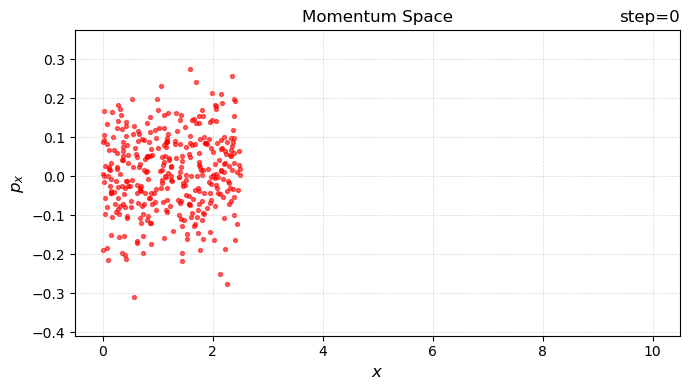

In [13]:
plt.figure(figsize=(7, 4))

plt.scatter(pdata_x_s1, pdata_ux_s1, s=8, alpha=0.6, label=r'$e-$', color='red')   # species 1: electrons
#plt.scatter(pdata_x_s2, pdata_ux_s2, s=8, alpha=0.6, label=r'$e+$', color='blue') # species 2: positrons

plt.xlim(-0.5, 10.5)       
plt.ylim(ymin-0.1, ymax+0.1)  
plt.xlabel(r'$x$', fontsize=12)
plt.ylabel(r'$p_x$', fontsize=12)
#plt.legend(frameon=False, fontsize=10)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
plt.title('Momentum Space', loc="center")
plt.title('step={}'.format(ind_out), loc="right")
plt.tight_layout()
plt.show()
#plt.savefig('run14/particles/electrons/t{}.png'.format(ind_out), dpi=300)

In [56]:
ind_out = np.arange(1, 820, 2)

for ind in ind_out:
    pdata_x = pdata.read_column(colname='x', step=ind)
    pdata_ux = pdata.read_column(colname='ux', step=ind)
    pdata_sp = pdata.read_column(colname='sp', step=ind)

    pdata_x_s1 = pdata_x[pdata_sp == 1]
    pdata_x_s2 = pdata_x[pdata_sp == 2]
    pdata_ux_s1 = pdata_ux[pdata_sp == 1]
    pdata_ux_s2 = pdata_ux[pdata_sp == 2]
    
    plt.figure(figsize=(7, 4))
    
    plt.scatter(pdata_x_s1, pdata_ux_s1, s=8, alpha=0.6,label=r'$e-$', color='red')    # electrons
    #plt.scatter(pdata_x_s2, pdata_ux_s2, s=8, alpha=0.6, label=r'$e+$', color='blue') # positrons
    
    plt.xlim(-0.5, 10.5)       
    plt.ylim(ymin-0.1, ymax+0.1)  
    plt.xlabel(r'$x$', fontsize=12)
    plt.ylabel(r'$p_x$', fontsize=12)
    #plt.legend(frameon=False, fontsize=10)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.title('Momentum Space', loc="center")
    plt.title('timestep={}'.format(ind), loc="right")
    plt.tight_layout()
    plt.savefig('run14/particles/electrons/t{}.png'.format(ind), dpi=300)
    plt.close()

## FIELDS

In [14]:
fdata = data.fields
print(fdata)

<xarray.Dataset> Size: 101MB
Dimensions:  (t: 1024, x: 2048)
Coordinates:
  * t        (t) float64 8kB 0.002441 0.007324 0.01221 ... 4.988 4.993 4.998
  * x        (x) float32 8kB 0.002441 0.007324 0.01221 ... 9.988 9.993 9.998
    s        (t) uint64 8kB 1 3 5 7 9 11 13 ... 2037 2039 2041 2043 2045 2047
    x_min    (x) float32 8kB 0.0 0.004883 0.009766 0.01465 ... 9.985 9.99 9.995
    x_max    (x) float32 8kB 0.004883 0.009766 0.01465 ... 9.99 9.995 10.0
Data variables:
    N_1      (t, x) float64 17MB dask.array<chunksize=(1, 2048), meta=np.ndarray>
    Ex       (t, x) float64 17MB dask.array<chunksize=(1, 2048), meta=np.ndarray>
    Charge   (t, x) float64 17MB dask.array<chunksize=(1, 2048), meta=np.ndarray>
    N_2      (t, x) float64 17MB dask.array<chunksize=(1, 2048), meta=np.ndarray>
    Ey       (t, x) float64 17MB dask.array<chunksize=(1, 2048), meta=np.ndarray>
    Ez       (t, x) float64 17MB dask.array<chunksize=(1, 2048), meta=np.ndarray>
Attributes: (12/92)
    Coordin

## Electric field over position

In [19]:
ind_out = 1023

ex_array = np.array(fdata.isel(t=ind_out).Ex.load())
x_array = np.array(fdata.isel(t=ind_out).x.load())

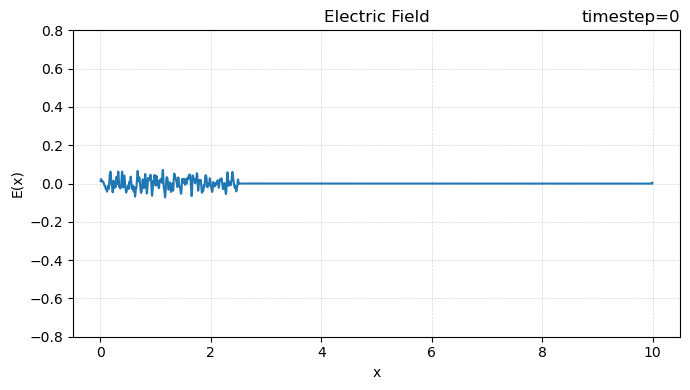

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(x_array, ex_array)
#plt.xlim(0, 100)       
plt.ylim(-0.8, 0.8)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
plt.xlabel(r'x')
plt.ylabel(r'E(x)')
plt.title('Electric Field', loc="center")
plt.title('timestep={}'.format(ind_out), loc="right")
plt.tight_layout()
plt.show()
#plt.savefig('run14/fields/t{}.png'.format(ind_out), dpi=300)

In [49]:
ind_out = np.arange(1, 820, 2)

for ind in ind_out:
    ex_array = np.array(fdata.isel(t=ind).Ex.load())
    x_array = np.array(fdata.isel(t=ind).x.load())

    plt.figure(figsize=(7, 4))
    plt.plot(x_array, ex_array, label = r'$E_x$')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.xlabel(r'x')
    plt.ylabel(r'E(x)')
    plt.title('Electric Field', loc="center")
    plt.title('timestep={}'.format(ind), loc="right")
    plt.tight_layout()
    plt.savefig('run14/fields/t{}.png'.format(ind), dpi=300)
    plt.close()

## SPECTRA

In [21]:
sdata = data.spectra
print(sdata)

<xarray.Dataset> Size: 3MB
Dimensions:  (t: 1024, E: 200)
Coordinates:
  * t        (t) float64 8kB 0.002441 0.007324 0.01221 ... 4.988 4.993 4.998
  * E        (E) float32 800B 0.001035 0.001109 0.001189 ... 841.4 901.6 966.1
    s        (t) uint64 8kB 1 3 5 7 9 11 13 ... 2037 2039 2041 2043 2045 2047
Data variables:
    N_1      (t, E) float64 2MB dask.array<chunksize=(1, 200), meta=np.ndarray>
    N_2      (t, E) float64 2MB dask.array<chunksize=(1, 200), meta=np.ndarray>
Attributes: (12/92)
    Coordinates:                      cart
    Dimension:                        1
    LayoutRight:                      0
    NGhosts:                          0
    algorithms.current_filters:       4
    algorithms.deposit.enable:        1
    ...                               ...
    setup.temperature:                0.01
    simulation.domain.decomposition:  [-1]
    simulation.domain.number:         1
    simulation.engine:                srpic
    simulation.name:                  single

### Distribution functions for all particle species in the box are also written with the data at specified timesteps. 
- These can be accessed via data.spectra, which has several different fields.
- As in particles & fields, you can access the data at different times using data.spectra.isel(t=...) or data.spectra.sel(t=...).
- The energy bins are written into data.spectra.E; by default, the binning is done logarithmically in γ−1 for massive particles and energy, E, for the photons.
- Below is an example script to build a distribution function of electron-positron pairs at output step t=450:

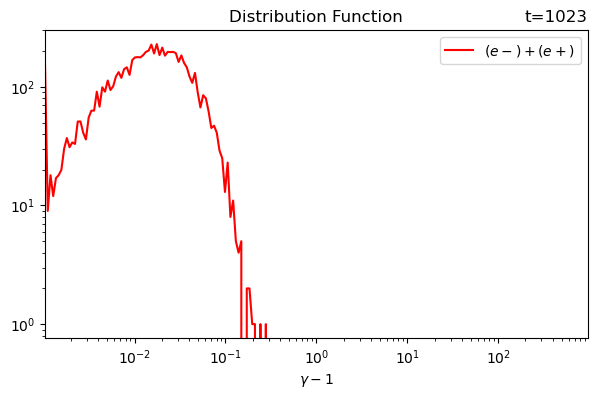

In [24]:
timestep=1023

sp = data.spectra.isel(t=timestep)
plt.figure(figsize=(7, 4))
plt.xscale("log")
plt.yscale("log")
plt.plot(sp.E, sp.N_1 + sp.N_2, c="r", label=r"$(e-)+(e+)$")
plt.legend(frameon=True, fontsize=10)
#plt.ylim(10, 1e3)
plt.xlabel(r"$\gamma - 1$")
plt.xlim(sp.E.min(), sp.E.max())
plt.title('Distribution Function', loc="center")
plt.title('t={}'.format(timestep), loc="right")
#plt.show()
plt.savefig('run14/spectra/electrons-positrons/t{}.png'.format(timestep), dpi=300)

In [10]:
'Electron-Positron Pairs'

timestep=np.arange(0,1024,1)

for step in timestep:

    sp = data.spectra.isel(t=1)
    plt.figure(figsize=(7, 4))
    plt.xscale("log")
    plt.yscale("log")
    plt.plot(sp.E, sp.N_1 + sp.N_2, c="r", label=r"$(e-)+(e+)$")
    plt.legend(frameon=True, fontsize=10)
    plt.ylim(10, 1e3)
    plt.xlabel(r"$\gamma - 1$")
    plt.xlim(sp.E.min(), sp.E.max())
    plt.title('Distribution Function', loc="center")
    plt.title('t={}'.format(step), loc="right")
    plt.savefig('run14/spectra/electrons-positrons/t{}.png'.format(step), dpi=300)
    plt.close()

In [11]:
'Electrons'

timestep=np.arange(0,1024,1)

for step in timestep:

    sp = data.spectra.isel(t=1)
    plt.figure(figsize=(7, 4))
    plt.xscale("log")
    plt.yscale("log")
    plt.plot(sp.E, sp.N_1, c="r", label=r"$e-$")
    plt.legend(frameon=True, fontsize=10)
    plt.ylim(10, 1e3)
    plt.xlabel(r"$\gamma - 1$")
    plt.xlim(sp.E.min(), sp.E.max())
    plt.title('Distribution Function', loc="center")
    plt.title('t={}'.format(step), loc="right")
    plt.savefig('run14/spectra/electrons/t{}.png'.format(step), dpi=300)
    plt.close()

In [12]:
'Positrons'

timestep=np.arange(0,1024,1)

for step in timestep:

    sp = data.spectra.isel(t=1)
    plt.figure(figsize=(7, 4))
    plt.xscale("log")
    plt.yscale("log")
    plt.plot(sp.E, sp.N_2, c="b", label=r"$e+$")
    plt.legend(frameon=True, fontsize=10)
    plt.ylim(10, 1e3)
    plt.xlabel(r"$\gamma - 1$")
    plt.xlim(sp.E.min(), sp.E.max())
    plt.title('Distribution Function', loc="center")
    plt.title('t={}'.format(step), loc="right")
    plt.savefig('run14/spectra/positrons/t{}.png'.format(step), dpi=300)
    plt.close()